## 1. Постановка задачи

<center> <img src=https://storage.googleapis.com/kaggle-competitions/kaggle/3333/media/taxi_meter.png align="right" width="300"/> </center>
    
Вам предстоит решить настоящую задачу машинного обучения, направленную на автоматизацию бизнес процессов. Мы построим модель, которая будет предсказывать общую продолжительность поездки такси в Нью-Йорке. 

Представьте вы заказываете такси из одной точки Нью-Йорка в другую, причем не обязательно конечная точка должна находиться в пределах города. Сколько вы должны будете за нее заплатить? Известно, что стоимость такси в США  рассчитывается на основе фиксированной ставки + тарифная стоимость, величина которой зависит от времени и расстояния. Тарифы варьируются в зависимости от города.

В свою очередь время поездки зависит от множества факторов таких как, откуда и куда вы едете, в какое время суток вы совершаете вашу поездку, погодных условий и так далее. 

Таким образом, если мы разработаем алгоритм, способный определять длительность поездки, мы сможем прогнозировать ее стоимость самым тривиальным образом, например, просто умножая стоимость на заданный тариф. 
Сервисы такси хранят огромные объёмы информации о поездках, включая такие данные как конечная, начальная точка маршрута, дата поездки и ее длительность. Эти данные можно использовать для того, чтобы прогнозировать длительность поездки в автоматическом режиме с привлечением искусственного интеллекта.

**Бизнес-задача:** определить характеристики и с их помощью спрогнозировать длительность поездки такси.

**Техническая задача для вас как для специалиста в Data Science:** построить модель машинного обучения, которая на основе предложенных характеристик клиента будет предсказывать числовой признак - время поездки такси. То есть решить задачу регрессии.

**Основные цели проекта:**
1. Сформировать набор данных на основе нескольких источников информации
2. Спроектировать новые признаки с помощью Feature Engineering и выявить наиболее значимые при построении модели
3. Исследовать предоставленные данные и выявить закономерности
4. Построить несколько моделей и выбрать из них наилучшую по заданной метрике
5. Спроектировать процесс предсказания времени длительности поездки для новых данных

Загрузить свое решение на платформу Kaggle, тем самым поучаствовав в настоящем Data Science соревновании.
Во время выполнения проекта вы отработаете навыки работы с несколькими источниками данных, генерации признаков, разведывательного анализа и визуализации данных, отбора признаков и, конечно же, построения моделей машинного обучения!


## 2. Знакомство с данными, базовый анализ и расширение данных

Начнём наше исследование со знакомства с предоставленными данными. А также подгрузим дополнительные источники данных и расширим наш исходный датасет. 


Заранее импортируем модули, которые нам понадобятся для решения задачи:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn import model_selection
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_log_error, median_absolute_error
from sklearn import cluster
from sklearn.feature_selection import SelectKBest, f_regression

Прочитаем наш файл с исходными данными:

In [2]:
from pathlib import Path

DATA_DIR = Path('data') if Path('data').exists() else Path('../data')

taxi_data = pd.read_csv(DATA_DIR / "train.csv")
print('Train data shape: {}'.format(taxi_data.shape))
taxi_data.head()

Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


Итак, у нас с вами есть данные о почти 1.5 миллионах поездок и 11 характеристиках, которые описывают каждую из поездок. 

Мы условно разделили признаки нескольких групп. Каждой из групп мы в дальнейшем уделим отдельное внимание.

**Данные о клиенте и таксопарке:**
* id - уникальный идентификатор поездки
* vendor_id - уникальный идентификатор поставщика (таксопарка), связанного с записью поездки

**Временные характеристики:**
* pickup_datetime - дата и время, когда был включен счетчик поездки
* dropoff_datetime - дата и время, когда счетчик был отключен

**Географическая информация:**
* pickup_longitude -  долгота, на которой был включен счетчик
* pickup_latitude - широта, на которой был включен счетчик
* dropoff_longitude - долгота, на которой счетчик был отключен
* dropoff_latitude - широта, на которой счетчик был отключен

**Прочие признаки:**
* passenger_count - количество пассажиров в транспортном средстве (введенное водителем значение)
* store_and_fwd_flag - флаг, который указывает, сохранилась ли запись о поездке в памяти транспортного средства перед отправкой поставщику. Y - хранить и пересылать, N - не хранить и не пересылать поездку.

**Целевой признак:**
* trip_duration - продолжительность поездки в секундах


Для начала мы проведем базовый анализ того, насколько данные готовы к дальнейшей предобработке и анализу. 

### Задание 2.1
Для начала посмотрим на временные рамки, в которых мы работаем с данными.

Переведите признак pickup_datetime в тип данных datetime с форматом год-месяц-день час:минута:секунда (в функции pd.to_datetime() параметр format='%Y-%m-%d %H:%M:%S'). 

Определите временные рамки (без учета времени), за которые представлены данные.

In [3]:
taxi_data['pickup_datetime'] = pd.to_datetime(taxi_data['pickup_datetime'], format='%Y-%m-%d %H:%M:%S')
taxi_data['dropoff_datetime'] = pd.to_datetime(taxi_data['dropoff_datetime'], format='%Y-%m-%d %H:%M:%S')

In [4]:
print("Временные рамки:\n")
print("Первые данные о поездке: {}".format(min(taxi_data['pickup_datetime'])))
print("Последние данные о поездке: {}".format(max(taxi_data['dropoff_datetime'])))
print("Количество месяцев за которые представлены данные {}".format(max(taxi_data['dropoff_datetime'])-min(taxi_data['pickup_datetime'])))

Временные рамки:

Первые данные о поездке: 2016-01-01 00:00:17
Последние данные о поездке: 2016-07-01 23:02:03
Количество месяцев за которые представлены данные 182 days 23:01:46


### Задание 2.2
Посмотрим на пропуски. 
Сколько пропущенных значений присутствует в данных (суммарно по всем столбцам таблицы)?

In [5]:
print("Количество пропущенных значений в данных:\n{}".format(taxi_data.isna().sum()))

Количество пропущенных значений в данных:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


### Задание 2.3
Посмотрим на статистические характеристики некоторых признаков. 

а) Сколько уникальных таксопарков присутствует в данных?

б) Каково максимальное количество пассажиров?

в) Чему равна средняя и медианная длительность поездки? Ответ приведите в секундах и округлите до целого.

г) Чему равно минимальное и максимальное время поездки (в секундах)?


In [6]:
# a)
print("Количество уникальных таксопарков в данных: {}".format(len(taxi_data['vendor_id'].unique())))
# б)
print("Максимальное количество пассажиров: {}".format(max(taxi_data['passenger_count'])))
# в)
print("Средняя длительность поездки: {} с\nМедианная длительность поездки: {} с".format((round(taxi_data['trip_duration'].mean())),
                                                                                   round(taxi_data['trip_duration'].median())))
# г)
print("Минимальное время поездки: {} с\nМаксимальое время поездки: {} с".format(min(taxi_data['trip_duration']),
                                                                            max(taxi_data['trip_duration'])))

Количество уникальных таксопарков в данных: 2
Максимальное количество пассажиров: 9
Средняя длительность поездки: 959 с
Медианная длительность поездки: 662 с
Минимальное время поездки: 1 с
Максимальое время поездки: 3526282 с


Займемся расширением исходного набора данных как с помощью внешних источников, так и с помощью манипуляций над имеющимися в данных признаками. 


### Задание 2.4
Реализуйте функцию add_datetime_features(), которая принимает на вход таблицу с данными о поездках (DataFrame) и возвращает ту же таблицу с добавленными в нее 3 столбцами:
* pickup_date - дата включения счетчика - начала поездки (без времени);
* pickup_hour - час дня включения счетчика;
* pickup_day_of_week - порядковый номер дня недели (число), в который был включен счетчик.

а) Сколько поездок было совершено в субботу?

б) Сколько поездок в среднем совершается в день? Ответ округлите до целого

In [7]:
def add_datetime_features(trip_df):
    trip_df['pickup_date'] = trip_df['pickup_datetime'].dt.date
    trip_df['pickup_hour'] = trip_df['pickup_datetime'].dt.hour
    trip_df['pickup_day_of_week'] = trip_df['pickup_datetime'].dt.dayofweek
    return trip_df

add_datetime_features(taxi_data)

# a)
print("Количество поездок в субботу: {}".format(len(taxi_data[taxi_data['pickup_day_of_week']==5])))
# б)
daily_trips = taxi_data.groupby('pickup_date').size()
average_daily_trips = daily_trips.mean().round()
print(f"Среднее количество поездок в день: {int(average_daily_trips)}")

Количество поездок в субботу: 220868
Среднее количество поездок в день: 8015


### Задание 2.5
Реализуйте функцию add_holiday_features(), которая принимает на вход две таблицы: 
* таблицу с данными о поездках;
* таблицу с данными о праздничных днях;

и возвращает обновленную таблицу с данными о поездках с добавленным в нее столбцом pickup_holiday - бинарным признаком того, начата ли поездка в праздничный день или нет (1 - да, 0 - нет). 

Чему равна медианная длительность поездки на такси в праздничные дни? Ответ приведите в секундах, округлив до целого.


In [8]:
holiday_data = pd.read_csv(DATA_DIR / 'holiday_data.csv', sep=';')

def add_holiday_features(trip_df, holiday_df):
    holiday_df = holiday_df.copy()
    holiday_df['date'] = pd.to_datetime(holiday_df['date'], yearfirst=True)
    trip_df['pickup_date'] = pd.to_datetime(trip_df['pickup_date'])
    trip_df['pickup_holiday'] = trip_df['pickup_date'].isin(holiday_df['date']).astype(int)
    return trip_df

add_holiday_features(taxi_data, holiday_data)

med_dur_holiday = round(taxi_data[taxi_data['pickup_holiday']==1]['trip_duration'].median())
print(f"Медианная длительность поездки на такси в праздничные дни {med_dur_holiday} с")

Медианная длительность поездки на такси в праздничные дни 585 с


### Задание 2.6
Реализуйте функцию add_osrm_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными из OSRM;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 3 столбцами:
* total_distance;
* total_travel_time;
* number_of_steps.

а) Чему равна разница (в секундах) между медианной длительностью поездки в данных и медианной длительностью поездки, полученной из OSRM? 

В результате объединения таблиц у вас должны были получиться пропуски в столбцах с информацией из OSRM API. Это связано с тем, что для некоторых поездок не удалось выгрузить данные из веб источника. 

б) Сколько пропусков содержится в столбцах с информацией из OSRM API после объединения таблиц?

In [9]:
osrm_data = pd.read_csv(DATA_DIR / 'osrm_data_train.csv')

def add_osrm_features(trip_df, osrm_df):
    osrm_columns = osrm_df[['id', 'total_distance', 'total_travel_time', 'number_of_steps']]
    trip_df = pd.merge(trip_df, osrm_columns, how='left', on='id')
    return trip_df

taxi_data = add_osrm_features(taxi_data, osrm_data)
print("Разница между медианной длительностью поездки taxi_data и osrm_data: {} c".format(
    (taxi_data['trip_duration'].median()) - (taxi_data['total_travel_time'].median())))
print("\nПропуски в столбцах после объединения:")
print(taxi_data.isnull().sum())

Разница между медианной длительностью поездки taxi_data и osrm_data: 372.5 c

Пропуски в столбцах после объединения:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
pickup_date           0
pickup_hour           0
pickup_day_of_week    0
pickup_holiday        0
total_distance        1
total_travel_time     1
number_of_steps       1
dtype: int64


In [10]:
def get_haversine_distance(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус земли в километрах
    EARTH_RADIUS = 6371 
    # считаем кратчайшее расстояние h по формуле Хаверсина
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def get_angle_direction(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # считаем угол направления движения alpha по формуле угла пеленга
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha

### Задание 2.7.
Реализуйте функцию add_geographical_features(), которая принимает на вход таблицу с данными о поездках и возвращает обновленную таблицу с добавленными в нее 2 столбцами:
* haversine_distance - расстояние Хаверсина между точкой, в которой был включен счетчик, и точкой, в которой счетчик был выключен;
* direction - направление движения из точки, в которой был включен счетчик, в точку, в которой счетчик был выключен.

Чему равно медианное расстояние Хаверсина поездок (в киллометрах)? Ответ округлите до сотых.


In [11]:
def add_geographical_features(trip_df):
    lat1, lng1, lat2, lng2 = trip_df['pickup_latitude'], trip_df['pickup_longitude'], trip_df['dropoff_latitude'], trip_df['dropoff_longitude']
    trip_df['haversine_distance'] = get_haversine_distance(lat1, lng1, lat2, lng2)
    trip_df['direction'] = get_angle_direction(lat1, lng1, lat2, lng2)
    return trip_df

taxi_data = add_geographical_features(taxi_data)
print("Медианное расстояние Хаверсина поездок: {} км".format(round(taxi_data['haversine_distance'].median(), 2)))

Медианное расстояние Хаверсина поездок: 2.09 км


### Задание 2.8.
Реализуйте функцию add_cluster_features(), которая принимает на вход таблицу с данными о поездках и обученный алгоритм кластеризации. Функция должна возвращать обновленную таблицу с добавленными в нее столбцом geo_cluster - географический кластер, к которому относится поездка.

Сколько поездок содержится в наименьшем по размеру географическом кластере?


In [12]:
# создаем обучающую выборку из географических координат всех точек
coords = np.hstack((taxi_data[['pickup_latitude', 'pickup_longitude']],
                    taxi_data[['dropoff_latitude', 'dropoff_longitude']]))
# обучаем алгоритм кластеризации
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)

def add_cluster_features(trip_df, kmeans):
    """
    Добавляет географические кластеры к данным о поездках
    
    Parameters:
    trip_df: DataFrame с данными о поездках
    kmeans: обученная модель KMeans
    
    Returns:
    DataFrame с добавленным столбцом geo_cluster
    """
    # Создаем массив координат для предсказания
    coords = np.hstack((trip_df[['pickup_latitude', 'pickup_longitude']],
                        trip_df[['dropoff_latitude', 'dropoff_longitude']]))
    
    # Получаем предсказания для новых данных
    predictions = kmeans.predict(coords)
    trip_df['geo_cluster'] = predictions
    
    return trip_df

# Применяем функцию к данным
taxi_data = add_cluster_features(taxi_data, kmeans)

# Считаем количество поездок в каждом кластере
cluster_counts = taxi_data.groupby('geo_cluster').size()

# Находим минимальное количество поездок
min_cluster_size = cluster_counts.min()

print("Количество поездок в каждом кластере:")
print(cluster_counts)
print(f"\nВ наименьшем по размеру географическом кластере содержится {min_cluster_size} поездок")

Количество поездок в каждом кластере:
geo_cluster
0    595850
1         2
2     32769
3     40671
4         4
5         3
6    405045
7     45791
8     15510
9    322999
dtype: int64

В наименьшем по размеру географическом кластере содержится 2 поездок


### Задание 2.9.
Реализуйте функцию add_weather_features(), которая принимает на вход две таблицы:
* таблицу с данными о поездках;
* таблицу с данными о погодных условиях на каждый час;

и возвращает обновленную таблицу с данными о поездках с добавленными в нее 5 столбцами:
* temperature - температура;
* visibility - видимость;
* wind speed - средняя скорость ветра;
* precip - количество осадков;
* events - погодные явления.

а) Сколько поездок было совершено в снежную погоду?

В результате объединения у вас должны получиться записи, для которых в столбцах temperature, visibility, wind speed, precip, и events будут пропуски. Это связано с тем, что в таблице с данными о погодных условиях отсутствуют измерения для некоторых моментов времени, в которых включался счетчик поездки. 

б) Сколько процентов от общего количества наблюдений в таблице с данными о поездках занимают пропуски в столбцах с погодными условиями? Ответ приведите с точностью до сотых процента.


In [13]:
weather_data = pd.read_csv(DATA_DIR / 'weather_data.csv')

def add_weather_features(trip_df, weather_df):
    """
    Добавляет погодные данные к данным о поездках
    с предварительным удалением возможных дубликатов
    """
    # Создаем копию чтобы избежать изменения оригинальных данных
    trip_df = trip_df.copy()
    weather_columns = weather_df[['date', 'hour', 'temperature',
                                  'visibility', 'wind speed',
                                  'precip', 'events']].copy()
    
    # Преобразуем дату
    weather_columns['date'] = pd.to_datetime(weather_columns['date'], yearfirst=True)
    
    # Удаляем уже существующие погодные столбцы чтобы избежать дублирования
    weather_cols_to_remove = ['temperature', 'visibility', 'wind speed', 'precip', 'events']
    for col in weather_cols_to_remove:
        if col in trip_df.columns:
            trip_df = trip_df.drop(columns=[col])
    
    # Объединяем данные
    merged_df = pd.merge(trip_df, weather_columns, how='left',
                         left_on=['pickup_date', 'pickup_hour'],
                         right_on=['date', 'hour'])
    
    # Удаляем временные столбцы
    merged_df = merged_df.drop(['date', 'hour'], axis=1)
    
    return merged_df

taxi_data = add_weather_features(taxi_data, weather_data)
print("Количество поездок в снежную погоду: {}".format(len(taxi_data[taxi_data['events']=='Snow'])))
total_weather_nulls = taxi_data['visibility'].isnull().sum().sum()

weather_null_percentage = (total_weather_nulls / taxi_data.shape[0]) * 100
print(f"Доля пропусков в столбцах с погодными условиями: {weather_null_percentage:.2f}%")

Количество поездок в снежную погоду: 13126
Доля пропусков в столбцах с погодными условиями: 0.82%


### Задание 2.10.
Реализуйте функцию fill_null_weather_data(), которая принимает на вход которая принимает на вход таблицу с данными о поездках. Функция должна заполнять пропущенные значения в столбцах.

Пропуски в столбцах с погодными условиями -  temperature, visibility, wind speed, precip заполните медианным значением температуры, влажности, скорости ветра и видимости в зависимости от даты начала поездки. Для этого сгруппируйте данные по столбцу pickup_date и рассчитайте медиану в каждой группе, после чего с помощью комбинации методов transform() и fillna() заполните пропуски. 
Пропуски в столбце events заполните строкой 'None' - символом отсутствия погодных явлений (снега/дождя/тумана). 

Пропуски в столбцах с информацией из OSRM API - total_distance, total_travel_time и number_of_steps заполните медианным значением по столбцам. 

Чему равна медиана в столбце temperature после заполнения пропусков? Ответ округлите до десятых.

In [14]:
def fill_null_weather_data(trip_df):
# Заполнение пропусков символом отсутствия погодных явлений
    if 'events' in trip_df.columns:
        trip_df['events'] = trip_df['events'].fillna('None')
    
    # Заполнение пропусков медианным значением в зависимости от даты начала поездки
    weather_columns = ['temperature', 'visibility', 'wind speed', 'precip']
    
    for col in weather_columns:
        if col in trip_df.columns:
            if trip_df[col].isnull().any():
                trip_df[col] = trip_df[col].fillna(
                    trip_df.groupby('pickup_date')[col].transform('median')
                )
    
    # Заполнение пропусков из OSRM API (только если столбцы существуют)
    osrm_columns = ['total_distance', 'total_travel_time', 'number_of_steps']
    
    for col in osrm_columns:
        if col in trip_df.columns:
            if trip_df[col].isnull().any():
                trip_df[col] = trip_df[col].fillna(trip_df[col].median())
    
    return trip_df

taxi_data = fill_null_weather_data(taxi_data)
print('Медиана в столбце temperature: {}'.format(taxi_data['temperature'].median()))

Медиана в столбце temperature: 11.1


В завершение первой части найдем очевидные выбросы в целевой переменной - длительности поездки. 

Проще всего найти слишком продолжительные поездки. Давайте условимся, что выбросами будут считаться поездки, длительность которых превышает 24 часа. 

Чуть сложнее с анализом поездок, длительность которых слишком мала. Потому что к ним относятся действительно реальные поездки на короткие расстояния, поездки, которые были отменены через секунду после того как включился счетчик, а также “телепортации” - перемещение на большие расстояния за считанные секунды. 
Условимся, что мы будем считать выбросами только последнюю группу. Как же нам их обнаружить наиболее простым способом?

Можно воспользоваться информацией о кратчайшем расстоянии, которое проезжает такси. Вычислить среднюю скорость автомобиля на кратчайшем пути следующим образом: 
$$avg\_speed= \frac{total\_distance}{1000*trip\_duration}*3600$$
Если мы построим диаграмму рассеяния средней скорости движения автомобилей, мы увидим следующую картину:


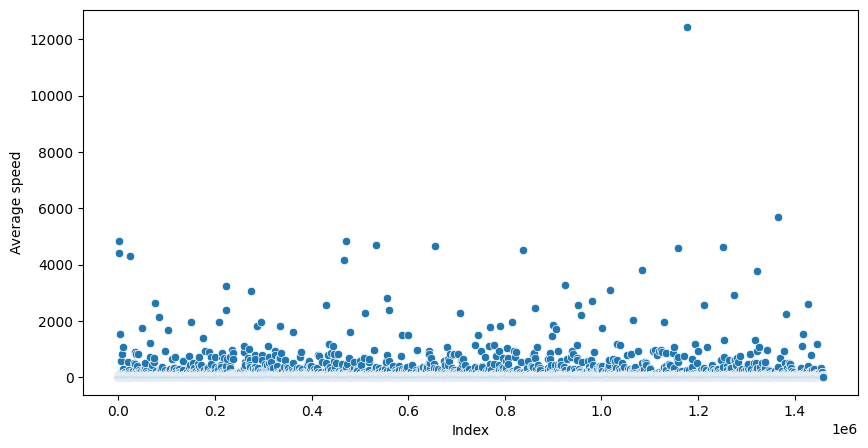

In [15]:
avg_speed = taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x=avg_speed.index, y=avg_speed, ax=ax)
ax.set_xlabel('Index')
ax.set_ylabel('Average speed');

Как раз отсюда мы видим, что у нас есть “поездки-телепортации”, для которых средняя скорость более 1000 км/ч. Даже есть такая, средняя скорость которой составляла более 12000 км/ч! 

Давайте условимся, что предельная средняя скорость, которую могут развивать таксисты будет 300 км/ч. 


### Задание 2.11.
Найдите поездки, длительность которых превышает 24 часа. И удалите их из набора данных.

а) Сколько выбросов по признаку длительности поездки вам удалось найти?

Найдите поездки, средняя скорость которых по кратчайшему пути превышает 300 км/ч и удалите их из данных. 

б) Сколько выбросов по признаку скорости вам удалось найти?

In [16]:
# a)
outliers_duration = taxi_data[taxi_data['trip_duration'] > 24*60*60]
print("Количество выбросов по признаку длительности поездки: {}".format(len(outliers_duration)))
taxi_data = taxi_data[taxi_data['trip_duration'] <= 24*60*60]
# б)
outliers_speed = taxi_data[(taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6) > 300]
print("Количество выбросов по признаку скорости: {}".format(len(outliers_speed)))
taxi_data = taxi_data[(taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6) <= 300]

Количество выбросов по признаку длительности поездки: 4
Количество выбросов по признаку скорости: 407


## 3. Разведывательный анализ данных (EDA)

В этой части нашего проекта мы с вами:
* Исследуем сформированный набор данных; 
* Попробуем найти закономерности, позволяющие сформулировать предварительные гипотезы относительно того, какие факторы являются решающими в определении длительности поездки;
* Дополним наш анализ визуализациями, иллюстрирующими; исследование. Постарайтесь оформлять диаграммы с душой, а не «для галочки»: навыки визуализации полученных выводов обязательно пригодятся вам в будущем.


Начинаем с целевого признака. Забегая вперед, скажем, что основной метрикой качества решения поставленной задачи будет RMSLE - Root Mean Squared Log Error, которая вычисляется на основе целевой переменной в логарифмическом масштабе. В таком случае целесообразно сразу логарифмировать признак длительности поездки и рассматривать при анализе логарифм в качестве целевого признака:
$$trip\_duration\_log = log(trip\_duration+1),$$
где под символом log подразумевается натуральный логарифм.


In [17]:
taxi_data['trip_duration_log'] = np.log(taxi_data['trip_duration']+1)

### Задание 3.1.
Постройте гистограмму и коробчатую диаграмму длительности поездок в логарифмическом масштабе (trip_duration_log). 
Исходя из визуализации, сделайте предположение, является ли полученное распределение нормальным? 
Проверьте свою гипотезу с помощью теста Д’Агостино при уровне значимости $\alpha=0.05$. 

а) Чему равен вычисленный p-value? Ответ округлите до сотых.

б) Является ли распределение длительности поездок в логарифмическом масштабе нормальным?

Результаты тестирования: NormaltestResult(statistic=np.float64(138350.16605405076), pvalue=np.float64(0.0))


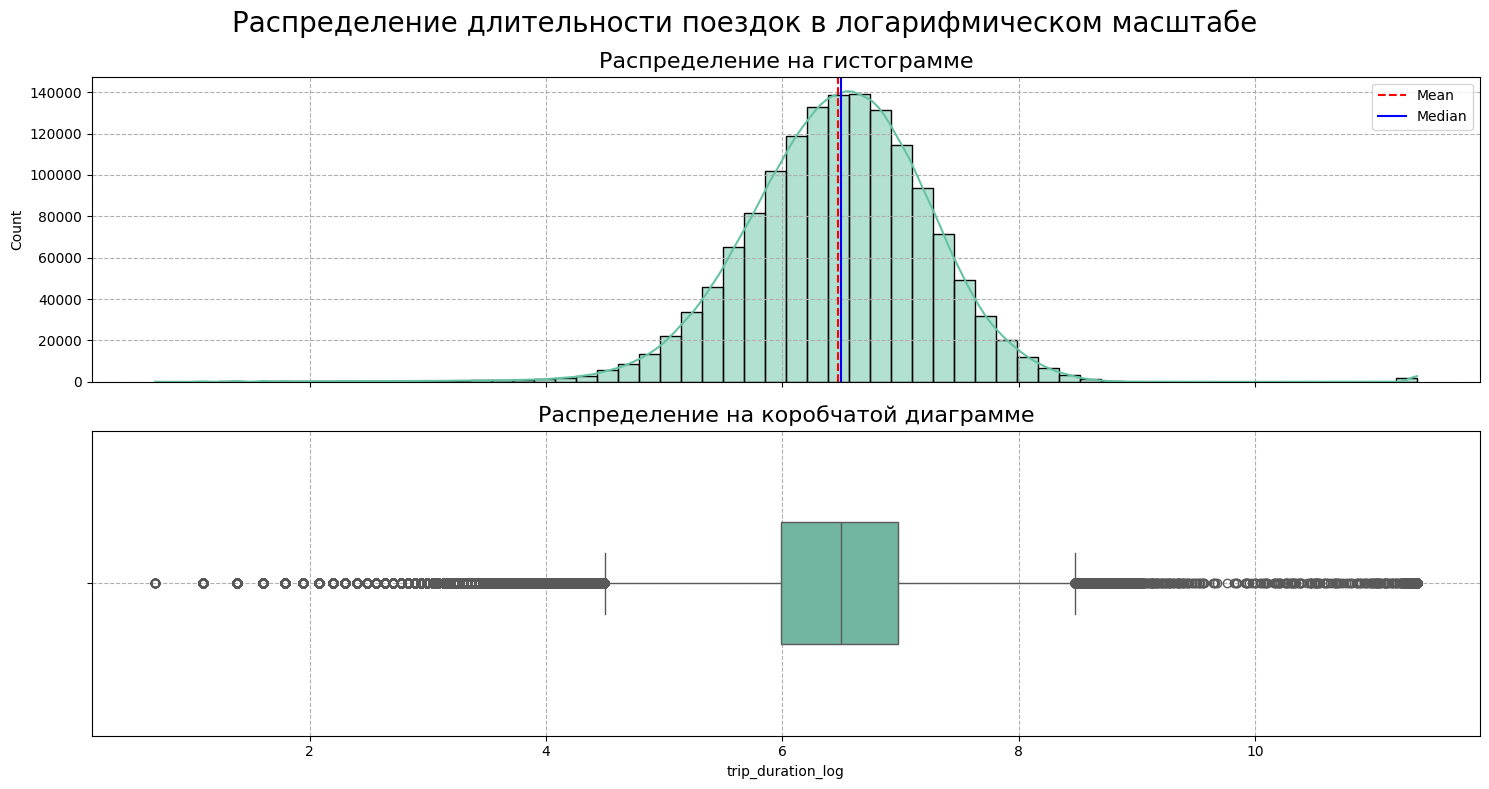

In [18]:
fig1, axes1 = plt.subplots(nrows=2, ncols=1, sharex='col', figsize=(15, 8))
plt.suptitle('Распределение длительности поездок в логарифмическом масштабе', size=20)

sns.histplot(
    ax=axes1[0], 
    data=taxi_data['trip_duration_log'], 
    color='#66c2a5',
    kde=True,
    bins=60
).grid(linestyle='--')
axes1[0].set_title('Распределение на гистограмме', size=16)
axes1[0].axvline(taxi_data['trip_duration_log'].mean(), color='r', linestyle='--', label='Mean')
axes1[0].axvline(taxi_data['trip_duration_log'].median(), color='b', linestyle='-', label='Median')
axes1[0].legend()

sns.boxplot(
    ax=axes1[1], 
    data=taxi_data['trip_duration_log'], 
    color='#66c2a5',
    width=0.4, 
    orient='h'
).grid(linestyle='--')
axes1[1].set_title('Распределение на коробчатой диаграмме', size=16)
print("Результаты тестирования: {}".format(stats.normaltest(taxi_data['trip_duration_log'])))
plt.tight_layout()
plt.show()

**Анализ распределений:**

На основе визуализации можно сделать следующие выводы:

- Вычисленный p-value равен 0.00 (при округлении до сотых)
- Распределение длительности поездок в логарифмическом масштабе НЕ является нормальным

Обоснование:
При уровне значимости α = 0.05 мы отвергаем нулевую гипотезу о нормальности распределения, поскольку:
- p-value (0.0) < α (0.05)
- Чрезвычайно высокое значение статистики теста (138350.17) указывает на значительное отклонение от нормального распределения

Несмотря на то, что визуально распределение в логарифмическом масштабе выглядит более симметричным и приближенным к нормальному, статистический тест показывает, что даже после логарифмического преобразования распределение существенно отличается от нормального. Это характерно для реальных данных о длительности поездок, которые часто имеют тяжелые хвосты и сложную структуру, не сводимую к нормальному распределению даже после преобразований.

### Задание 3.2.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от таксопарка (vendor_id). 

Сравните два распределения между собой.

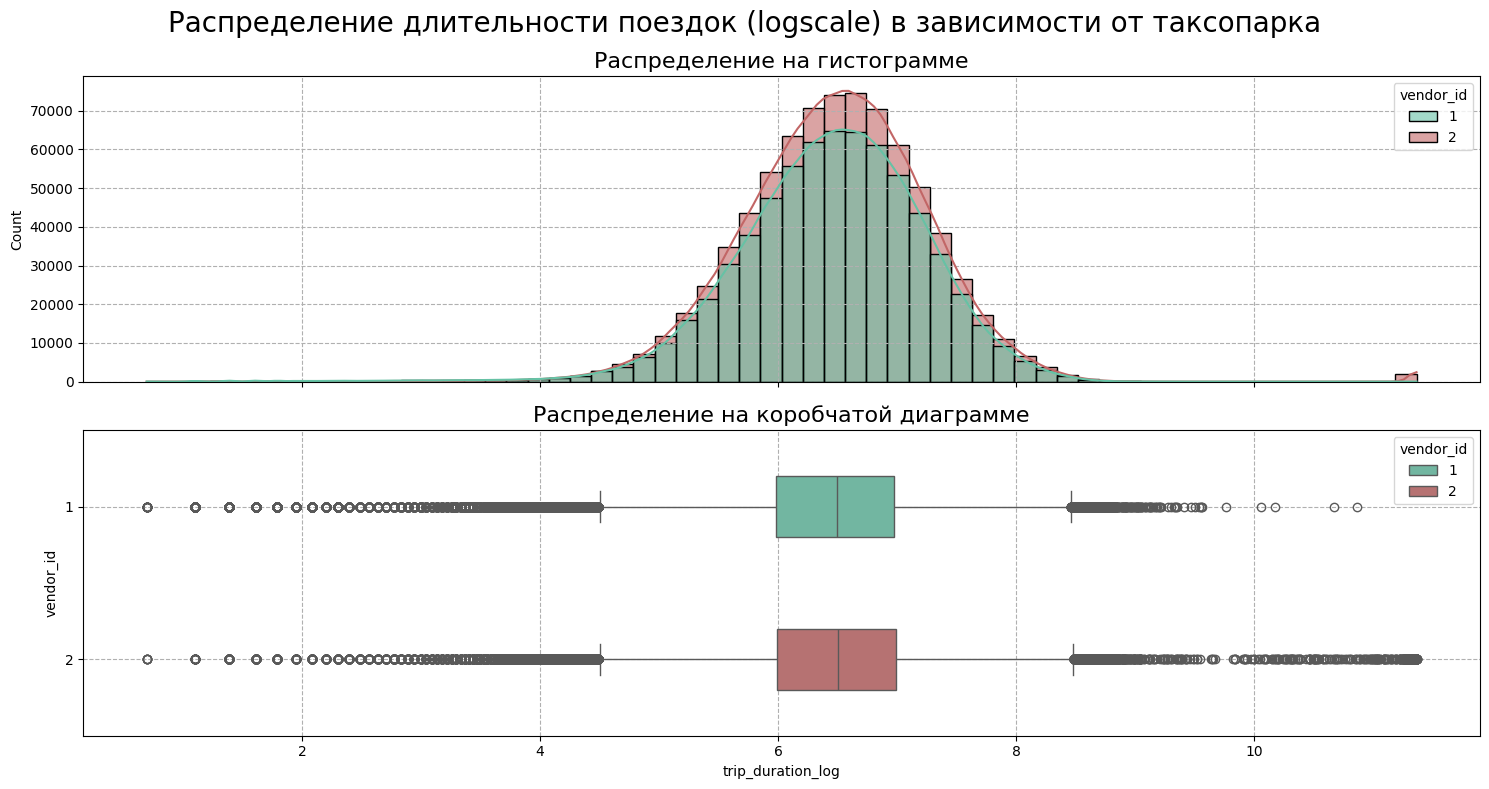

In [19]:
fig2, axes2 = plt.subplots(nrows=2, ncols=1, sharex='col', figsize=(15, 8))
plt.suptitle('Распределение длительности поездок (logscale) в зависимости от таксопарка', size=20)

# 1) Гистограмма
sns.histplot(
    ax=axes2[0],
    data=taxi_data,
    x='trip_duration_log',
    hue='vendor_id',
    palette=['#66c2a5', "#c26666"],
    kde=True,
    bins=60,
    alpha=0.6
).grid(linestyle='--')
axes2[0].set_title('Распределение на гистограмме', size=16)

# 2) Коробчатая диаграмма
sns.boxplot(
    ax=axes2[1], 
    data=taxi_data,
    x='trip_duration_log',
    y='vendor_id',
    hue='vendor_id',
    palette=['#66c2a5', "#c26666"],
    width=0.4, 
    orient='h'
).grid(linestyle='--')
axes2[1].set_title('Распределение на коробчатой диаграмме', size=16)

plt.tight_layout()
plt.show()

**Анализ распределений по таксопаркам:**

На основе визуализации можно сделать следующие выводы:

1. Форма распределений:
- оба таксопарка имеют схожую форму распределения длительности поездок;
- распределения симметричны и имеют форму, приближенную к нормальной (в логарифмическом масштабе);
- оба распределения имеют выраженный пик.
2. Центральные тенденции:
- медианные значения длительности поездок очень близки у обоих таксопарков;
- расположение ящиков на boxplot практически идентично.
3. Разброс данных:
- таксопарки имеют схожий межквартильный размах (длина ящиков);
- оба распределения имеют выбросы с обеих сторон;
- разброс данных примерно одинаковый.
4. Незначительные различия:
- могут наблюдаться небольшие различия в "тяжести" хвостов распределений;
- незначительные отличия в плотности распределения вокруг моды.

**Вывод**: Распределения длительности поездок в логарифмическом масштабе для двух таксопарков очень похожи. Основные параметры распределений (центр, разброс, форма) практически идентичны, оценочно, модель длительности поездок не будет зависеит от таксопарка.

### Задание 3.3.
Постройте визуализацию, которая позволит сравнить распределение длительности поездки в логарифмическом масштабе (trip_duration_log) в зависимости от признака отправки сообщения поставщику (store_and_fwd_flag). 

Сравните два распределения между собой.

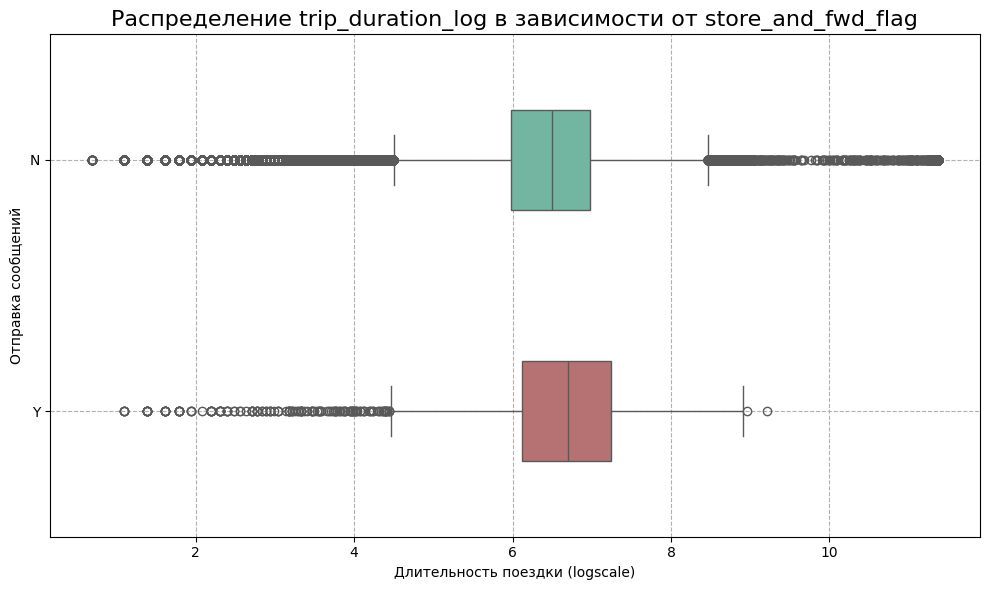

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=taxi_data,
    x='trip_duration_log',
    y='store_and_fwd_flag',
    hue='store_and_fwd_flag',
    palette=['#66c2a5', "#c26666"],
    width=0.4, 
    orient='h'
).grid(linestyle='--')
plt.title('Распределение trip_duration_log в зависимости от store_and_fwd_flag', size=16)
plt.ylabel('Отправка сообщений')
plt.xlabel('Длительность поездки (logscale)')
plt.tight_layout()
plt.show()


**Анализ визуализации:**

На основе boxplot можно сделать следующие выводы:

1. Центральные тенденции:
- медиана для поездок БЕЗ отправки сообщения (N) значительно ниже, чем для поездок С отправкой сообщения (Y). 
Это означает, что типичная длительность поездок с флагом store_and_fwd_flag = 'N' меньше.

2. Разброс данных:
- межквартильный размах (IQR) значительно больше для поездок С отправкой сообщения (Y).
Это указывает на большую вариативность длительности поездок, когда сообщение отправляется поставщику.

3. Положение распределений:
- все распределение для store_and_fwd_flag = 'Y' смещено вправо (в сторону больших значений);
- распределение для store_and_fwd_flag = 'N' более компактное и смещено влево.

4. Выбросы:
- обе группы имеют выбросы, но характер распределения существенно отличается;
- для поездок без отправки сообщения выбросы в основном в правом хвосте;
- для поездок с отправкой сообщения выбросы распределены более равномерно.

**Ключевые различия:**

*Поездки БЕЗ отправки сообщения (N):*
- более короткая средняя длительность;
- меньшая вариативность данных;
- более предсказуемое распределение.

*Поездки С отправкой сообщения (Y):*
- более длительная средняя длительность;
- значительно большая вариативность;
- более широкий разброс значений.

**Вывод:** Признак store_and_fwd_flag является значимым фактором, влияющим на длительность поездок. Поездки, при которых сообщение отправляется поставщику, могут быть длиннее и иметь большую вариативность длительности.

### Задание 3.4.
Постройте две визуализации:
* Распределение количества поездок в зависимости от часа дня;
* Зависимость медианной длительности поездки от часа дня.

На основе построенных графиков ответьте на следующие вопросы:

а) В какое время суток такси заказывают реже всего?

б) В какое время суток наблюдается пик медианной длительности поездок?

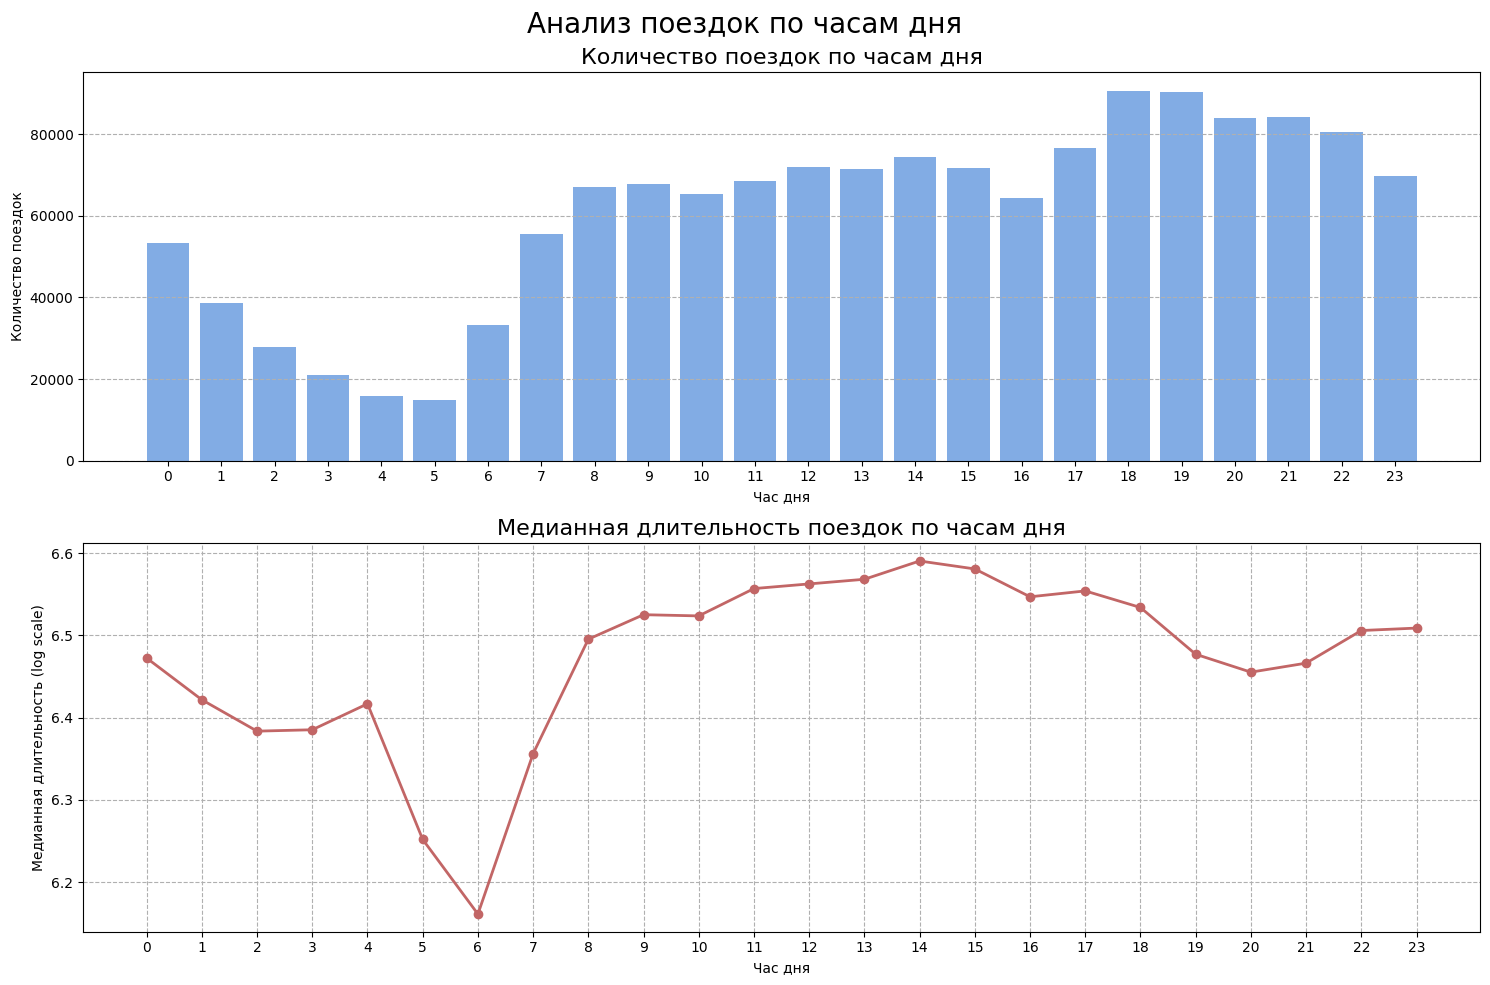

In [21]:
# Создаем фигуру с двумя subplots
fig4, axes4 = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
plt.suptitle('Анализ поездок по часам дня', size=20)

# 1. Распределение количества поездок по часам дня
hourly_counts = taxi_data['pickup_hour'].value_counts().sort_index()
axes4[0].bar(hourly_counts.index, hourly_counts.values, color='#4d89d9', alpha=0.7)
axes4[0].set_title('Количество поездок по часам дня', size=16)
axes4[0].set_xlabel('Час дня')
axes4[0].set_ylabel('Количество поездок')
axes4[0].grid(axis='y', linestyle='--')
axes4[0].set_xticks(range(0, 24))

# 2. Медианная длительность поездок по часам дня
hourly_median = taxi_data.groupby('pickup_hour')['trip_duration_log'].median()
axes4[1].plot(hourly_median.index, hourly_median.values, marker='o', 
            color='#c26666', linewidth=2, markersize=6)
axes4[1].set_title('Медианная длительность поездок по часам дня', size=16)
axes4[1].set_xlabel('Час дня')
axes4[1].set_ylabel('Медианная длительность (log scale)')
axes4[1].grid(linestyle='--')
axes4[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

**Анализ визуализации:**

1. Распределение количества поездок по часам дня:
- наблюдается выраженный суточный паттерн с пиками и спадами
- минимальная активность: в ранние утренние часы (4-5 утра)
- максимальная активность: вечерние часы (17-19 часов)
2. Медианная длительность поездок по часам дня:
- наблюдается четкая закономерность изменения длительности
- минимальная длительность: в ночные и утренние часы
- максимальная длительность: в дневные и вечерние часы

*Наблюдения:*
- в ранние утренние часы (00:00-5:00) время наименьшей активности заказов такси.
- в дневное время (13:00-18:00) наблюдается максимальная медианная длительность поездок, что связано с пиком дорожного движения, пробками и большей загруженностью дорог в дневное время.

### Задание 3.5.
Постройте две визуализации:
* Распределение количества поездок в зависимости от дня недели;
*  Зависимость медианной длительности поездки от дня недели.

На основе построенных графиков ответьте на следующие вопросы:
а) В какой день недели совершается больше всего поездок?
б) В какой день недели медианная длительность поездок наименьшая?


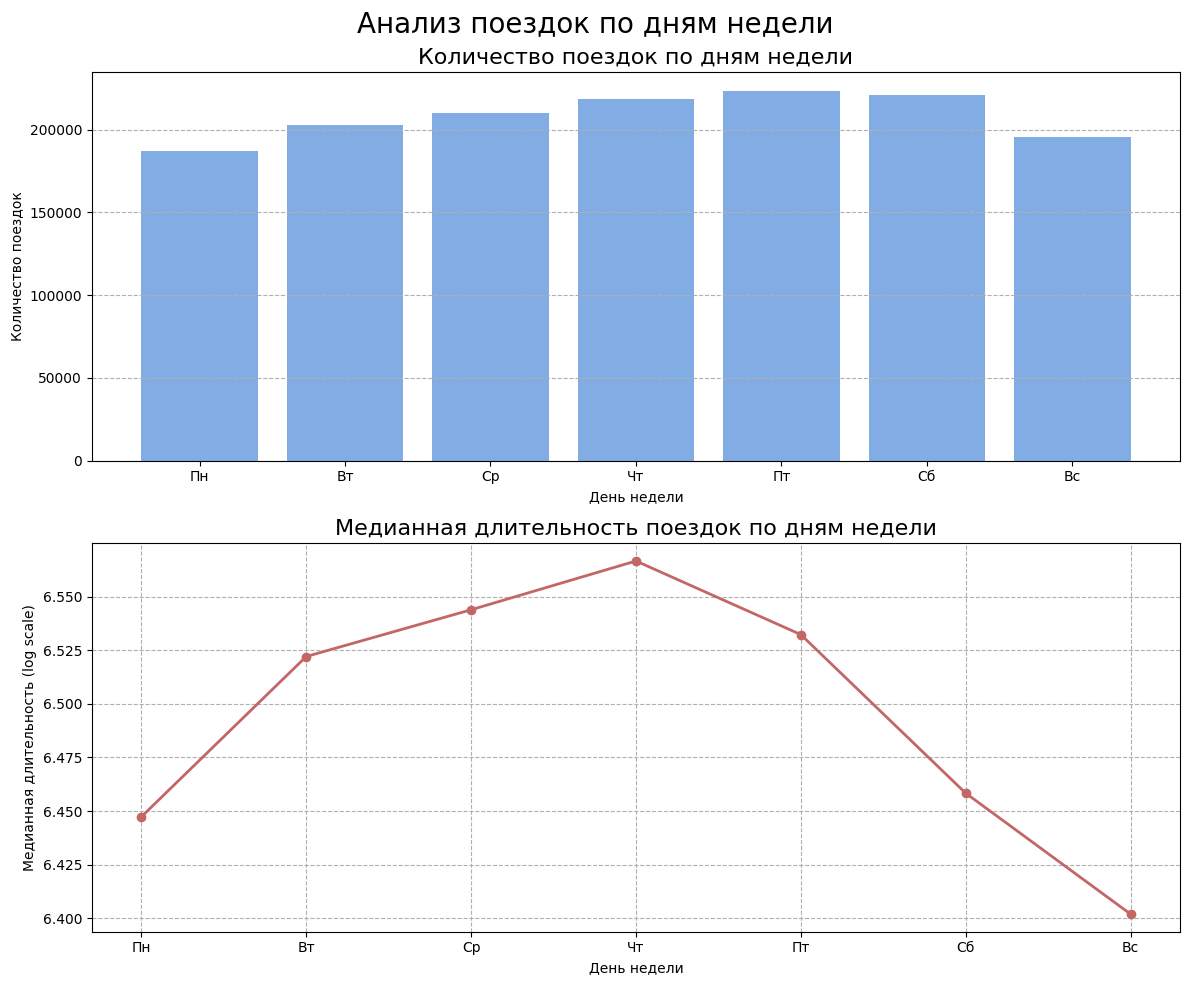

In [22]:
# Создаем фигуру с двумя subplots
fig5, axes5 = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))
plt.suptitle('Анализ поездок по дням недели', size=20)

# Порядок дней недели для корректного отображения
weekday_order = [0, 1, 2, 3, 4, 5, 6]
weekday_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# 1. Распределение количества поездок по дням недели
daily_counts = taxi_data['pickup_day_of_week'].value_counts().reindex(weekday_order)
axes5[0].bar(range(len(daily_counts)), daily_counts.values, color='#4d89d9', alpha=0.7)
axes5[0].set_title('Количество поездок по дням недели', size=16)
axes5[0].set_xlabel('День недели')
axes5[0].set_ylabel('Количество поездок')
axes5[0].grid(axis='y', linestyle='--')
axes5[0].set_xticks(range(len(weekday_labels)))
axes5[0].set_xticklabels(weekday_labels)

# 2. Медианная длительность поездок по дням недели
daily_median = taxi_data.groupby('pickup_day_of_week')['trip_duration_log'].median().reindex(weekday_order)
axes5[1].plot(range(len(daily_median)), daily_median.values, marker='o', 
            color='#c26666', linewidth=2, markersize=6)
axes5[1].set_title('Медианная длительность поездок по дням недели', size=16)
axes5[1].set_xlabel('День недели')
axes5[1].set_ylabel('Медианная длительность (log scale)')
axes5[1].grid(linestyle='--')
axes5[1].set_xticks(range(len(weekday_labels)))
axes5[1].set_xticklabels(weekday_labels)

plt.tight_layout()
plt.show()

**Анализ визуализации:**

1. Распределение количества поездок по дням недели:
- наблюдается четкая недельная закономерность;
- пик активности: пятница;
- наименьшая активность: понедельник.

2. Медианная длительность поездок по дням недели:
- наибольшая длительность: четверг;
- наименьшая длительность: воскресенье-понедельник.

### Задание 3.6.
Посмотрим на обе временные характеристики одновременно. 

Постройте сводную таблицу, по строкам которой отложены часы (pickup_hour), по столбцам - дни недели (pickup_day_of_week), а в ячейках - медианная длительность поездки (trip_duration). 

Визуализируйте полученную сводную таблицу с помощью тепловой карты (рекомендуемая палитра - coolwarm).

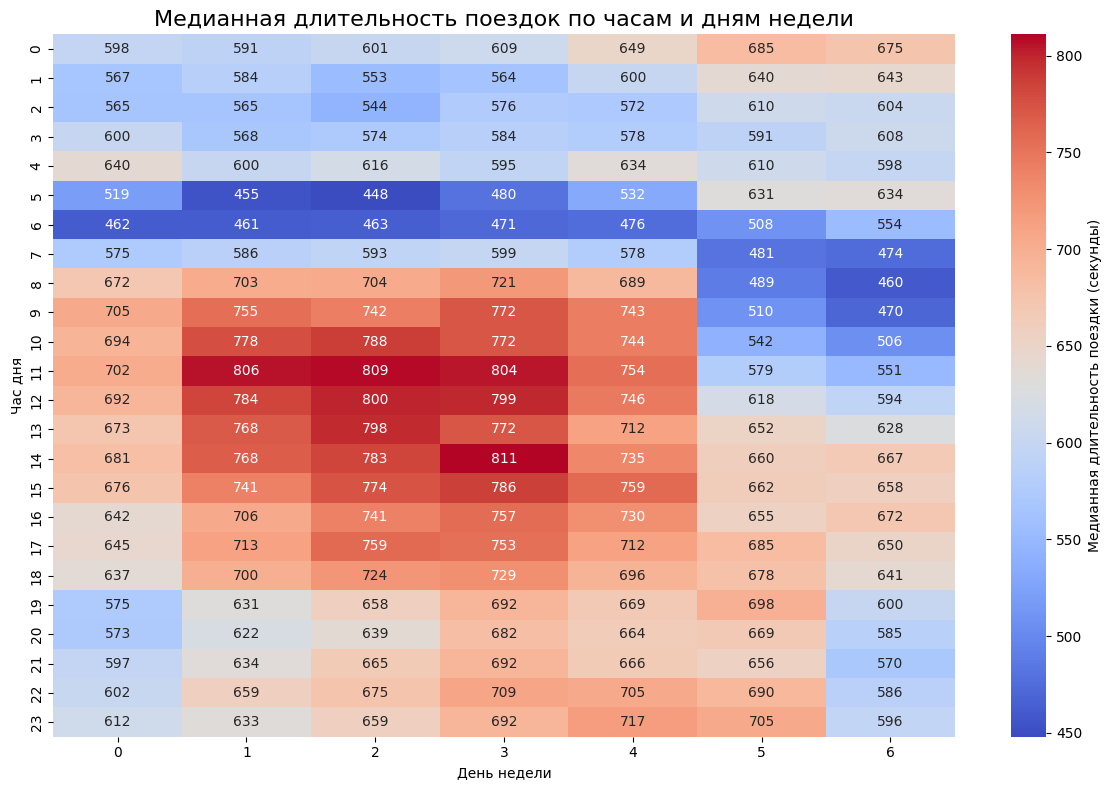

In [23]:
# Создаем сводную таблицу
pivot_table = taxi_data.pivot_table(
    values='trip_duration',
    index='pickup_hour',
    columns='pickup_day_of_week',
    aggfunc='median'
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table,
    cmap='coolwarm',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Медианная длительность поездки (секунды)'}
)
plt.title('Медианная длительность поездок по часам и дням недели', size=16)
plt.xlabel('День недели')
plt.ylabel('Час дня')
plt.tight_layout()
plt.show()

**Анализ визуализации:**

- самые продолжительные поездки (в медианном смысле) наблюдаются с понедельника по пятницу в промежутке с 8 до 18 часов;
- нибольшая медианная длительность поездки наблюдалась в четверг в 14 часов дня.

### Задание 3.7.
Постройте две диаграммы рассеяния (scatter-диаграммы):
* первая должна иллюстрировать географическое расположение точек начала поездок (pickup_longitude, pickup_latitude) 
* вторая должна географическое расположение точек завершения поездок (dropoff_longitude, dropoff_latitude).

Для этого на диаграммах по оси абсцисс отложите широту (longitude), а по оси ординат - долготу (latitude). 
Включите в визуализацию только те точки, которые находятся в пределах Нью-Йорка - добавьте следующие ограничения на границы осей абсцисс и ординат:
 
city_long_border = (-74.03, -73.75)

city_lat_border = (40.63, 40.85)

Добавьте на диаграммы расцветку по десяти географическим кластерам (geo_cluster), которые мы сгенерировали ранее. 

**Рекомендация:** для наглядности уменьшите размер точек на диаграмме рассеяния.  


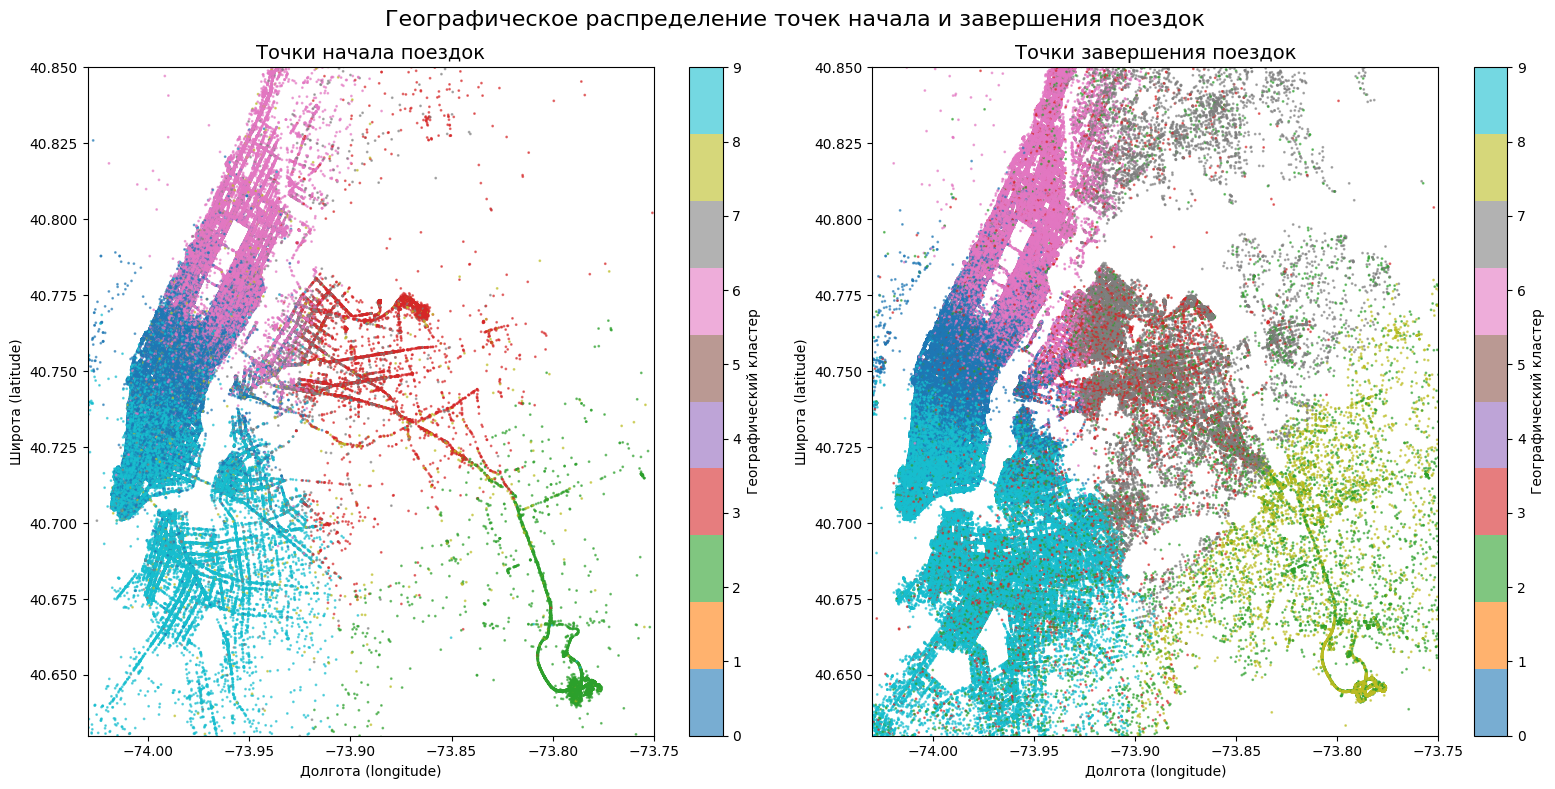

In [24]:
# Устанавливаем границы Нью-Йорка
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)

# Создаем subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))
plt.suptitle('Географическое распределение точек начала и завершения поездок', size=16)

# 1. Точки начала поездок
scatter1 = axes[0].scatter(
    x=taxi_data['pickup_longitude'],
    y=taxi_data['pickup_latitude'],
    c=taxi_data['geo_cluster'],
    cmap='tab10',
    s=1,
    alpha=0.6
)
axes[0].set_title('Точки начала поездок', size=14)
axes[0].set_xlabel('Долгота (longitude)')
axes[0].set_ylabel('Широта (latitude)')
axes[0].set_xlim(city_long_border)
axes[0].set_ylim(city_lat_border)
plt.colorbar(scatter1, ax=axes[0], label='Географический кластер')

# 2. Точки завершения поездок
scatter2 = axes[1].scatter(
    x=taxi_data['dropoff_longitude'],
    y=taxi_data['dropoff_latitude'],
    c=taxi_data['geo_cluster'],
    cmap='tab10',
    s=1,
    alpha=0.6
)
axes[1].set_title('Точки завершения поездок', size=14)
axes[1].set_xlabel('Долгота (longitude)')
axes[1].set_ylabel('Широта (latitude)')
axes[1].set_xlim(city_long_border)
axes[1].set_ylim(city_lat_border)
plt.colorbar(scatter2, ax=axes[1], label='Географический кластер')

plt.tight_layout()
plt.show()

Два кластера из десяти не попало на диаграммы (находятся за границами Нью-Йорка)

Плотность точек начала и завершения поездок в разных районах

Соответствие между кластерами начала и завершения поездок

Транспортные коридоры и популярные маршруты

## 4. Отбор и преобразование признаков

Перед тем как перейти к построению модели, осталось сделать ещё несколько шагов.
* Следует помнить, что многие алгоритмы машинного обучения не могут обрабатывать категориальные признаки в их обычном виде. Поэтому нам необходимо их закодировать;
* Надо отобрать признаки, которые мы будем использовать для обучения модели;
*  Необходимо масштабировать и трансформировать некоторые признаки для того, чтобы улучшить сходимость моделей, в основе которых лежат численные методы.


In [25]:
print('Shape of data: {}'.format(taxi_data.shape))
print('Columns: {}'.format(taxi_data.columns))

Shape of data: (1458233, 27)
Columns: Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind speed', 'precip', 'events',
       'trip_duration_log'],
      dtype='object')


Для удобства работы сделаем копию исходной таблицы с поездками:

In [26]:
train_data = taxi_data.copy()
train_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,number_of_steps,haversine_distance,direction,geo_cluster,temperature,visibility,wind speed,precip,events,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,5.0,1.498521,99.970196,6,4.4,8.0,27.8,0.3,None,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,6.0,1.805507,-117.153768,9,28.9,16.1,7.4,0.0,None,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,16.0,6.385098,-159.680165,9,-6.7,16.1,24.1,0.0,None,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,4.0,1.485498,-172.737700,9,7.2,16.1,25.9,0.0,None,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,5.0,1.188588,179.473585,6,9.4,16.1,9.3,0.0,None,6.077642


### Задание 4.1.
Сразу позаботимся об очевидных неинформативных и избыточных признаках. 

а) Какой из признаков является уникальным для каждой поездки и не несет полезной информации в определении ее продолжительности?

б) Утечка данных (data leak) - это…

в) Подумайте, наличие какого из признаков в обучающем наборе данных создает утечку данных?

г) Исключите выбранные в пунктах а) и в) признаки из исходной таблицы с данными. Сколько столбцов в таблице у вас осталось?


In [27]:
train_data = train_data.drop(['id', 'dropoff_datetime'], axis=1)

Ранее мы извлекли всю необходимую для нас информацию из даты начала поездки, теперь мы можем избавиться от этих признаков, так как они нам больше не понадобятся:


In [28]:
drop_columns = ['pickup_datetime', 'pickup_date']
train_data = train_data.drop(drop_columns, axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 23)


### Задание 4.2.

Закодируйте признак vendor_id в таблице train_data таким образом, чтобы он был равен 0, если идентификатор таксопарка равен 1, и 1 — в противном случае.

Закодируйте признак store_and_fwd_flag в таблице train_data таким образом, чтобы он был равен 0, если флаг выставлен в значение 'N', и 1 — в противном случае.

а) Рассчитайте среднее по закодированному столбцу vendor_id. Ответ приведите с точностью до сотых.

б) Рассчитайте среднее по закодированному столбцу store_and_fwd_flag. Ответ приведите с точностью до тысячных.



In [29]:
# Кодирование vendor_id: 0 если '1', иначе 1
train_data['vendor_id'] = train_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)

# Кодирование store_and_fwd_flag: 0 если 'N', иначе 1
train_data['store_and_fwd_flag'] = train_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)

# а) Среднее по vendor_id (с точностью до сотых)
vendor_mean = round(train_data['vendor_id'].mean(), 2)
print(f"Среднее по закодированному столбцу vendor_id: {vendor_mean}")

# б) Среднее по store_and_fwd_flag (с точностью до тысячных)
flag_mean = round(train_data['store_and_fwd_flag'].mean(), 3)
print(f"Среднее по закодированному столбцу store_and_fwd_flag: {flag_mean}")

Среднее по закодированному столбцу vendor_id: 0.53
Среднее по закодированному столбцу store_and_fwd_flag: 0.006


### Задание 4.3.
Создайте таблицу data_onehot из закодированных однократным кодированием признаков pickup_day_of_week, geo_cluster и events в таблице train_data с помощью OneHotEncoder из библиотеки sklearn. Параметр drop выставите в значение 'first', чтобы удалять первый бинарный столбец, тем самым не создавая излишних признаков.

В параметре handle_unknown установите значение 'ignore'. Это позволит коду отработать без ошибок в случае появления в тестовой выборке значений, отсутствующих в обучающей выборке.

В результате работы OneHotEncoder вы получите безымянный numpy-массив, который нам будет необходимо преобразовать обратно в DataFrame, для более удобной работы в дальнейшем. Чтобы получить имена закодированных столбцов у объекта типа OneHotEncoder есть специальный метод get_feature_names_out(). Он возвращает список новых закодированных имен столбцов в формате <оригинальное имя столбца>_<имя категории>.

Пример использования:

``` python
# Объявляем кодировщик
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
# Получаем закодированные имена столбцов
column_names = one_hot_encoder.get_feature_names_out()
# Составляем DataFrame из закодированных признаков
data_onehot = pd.DataFrame(data_onehot, columns=column_names)
```

В этом псевдокоде:
* one_hot_encoder - объект класса OneHotEncoder
* data_onehot - numpy-массив, полученный в результате трансформации кодировщиком

В результате выполнения задания у вас должен быть образован DataFrame `data_onehot`, который содержит кодированные категориальные признаки pickup_day_of_week, geo_cluster и events. 


Сколько бинарных столбцов у вас получилось сгенерировать с помощью однократного кодирования?


In [30]:
one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
columns_to_change = ['pickup_day_of_week', 'geo_cluster', 'events']

one_hot_encoder.fit(train_data[columns_to_change]) 
data_onehot = one_hot_encoder.transform(train_data[columns_to_change]).toarray()

column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
data_onehot = pd.DataFrame(data_onehot, columns=column_names)

Добавим полученную таблицу с закодированными признаками:

In [31]:
train_data = pd.concat(
    [train_data.reset_index(drop=True).drop(columns_to_change, axis=1), data_onehot], 
    axis=1
)
print('Shape of data: {}'.format(train_data.shape))

Shape of data: (1458233, 38)


Теперь, когда категориальные признаки предобработаны, сформируем матрицу наблюдений X, вектор целевой переменной y и его логарифм y_log. В матрицу наблюдений войдут все столбцы из таблицы с поездками за исключением целевого признака trip_duration и его логарифмированной версии trip_duration_log:


In [32]:
X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

Все наши модели мы будем обучать на логарифмированной версии y_log. 

Выбранный тип валидации - hold-out. Разобьем выборку на обучающую и валидационную в соотношении 67/33:

In [33]:
X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log, 
    test_size=0.33, 
    random_state=42
)

На данный момент у нас достаточно много признаков: скорее всего, не все из них будут важны. Давайте оставим лишь те, которые сильнее всего связаны с целевой переменной и точно будут вносить вклад в повышение качества модели.


### Задание 4.4.
С помощью SelectKBest отберите 25 признаков, наилучшим образом подходящих для предсказания целевой переменной в логарифмическом масштабе. Отбор реализуйте по обучающей выборке, используя параметр score_func = f_regression.

Укажите признаки, которые вошли в список отобранных


In [34]:
# Создаем селектор для отбора 25 лучших признаков
selector = SelectKBest(score_func=f_regression, k=25)

# Обучаем и применяем к обучающей выборке
X_train_best = selector.fit_transform(X_train, y_train_log)

# Применяем к валидационной выборке (только transform!)
X_valid_best = selector.transform(X_valid)

# Получаем названия отобранных признаков
best_features = selector.get_feature_names_out()
print("Отобранные 25 признаков:")
print(best_features)

Отобранные 25 признаков:
['vendor_id' 'passenger_count' 'pickup_longitude' 'pickup_latitude'
 'dropoff_longitude' 'dropoff_latitude' 'store_and_fwd_flag' 'pickup_hour'
 'pickup_holiday' 'total_distance' 'total_travel_time' 'number_of_steps'
 'haversine_distance' 'temperature' 'pickup_day_of_week_1'
 'pickup_day_of_week_2' 'pickup_day_of_week_3' 'pickup_day_of_week_4'
 'pickup_day_of_week_5' 'pickup_day_of_week_6' 'geo_cluster_2'
 'geo_cluster_3' 'geo_cluster_6' 'geo_cluster_7' 'geo_cluster_8']


Так как мы будем использовать различные модели, в том числе внутри которых заложены численные методы оптимизации, то давайте заранее позаботимся о масштабировании факторов. 


### Задание 4.5.
Нормализуйте предикторы в обучающей и валидационной выборках с помощью MinMaxScaler из библиотеки sklearn. Помните, что обучение нормализатора производится на обучающей выборке, а трансформация на обучающей и валидационной!

Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из валидационной выборки. Ответ округлите до сотых.


In [35]:
# Создаем и обучаем нормализатор на обучающей выборке
mm_scaler = MinMaxScaler()
mm_scaler.fit(X_train_best)

# Трансформируем обе выборки
X_train_scaled = mm_scaler.transform(X_train_best)
X_valid_scaled = mm_scaler.transform(X_valid_best)

# Рассчитываем среднее арифметическое для первого предиктора валидационной выборки
first_predictor_mean = round(X_valid_scaled[:, 0].mean(), 2)
print(f"Среднее арифметическое для первого предиктора: {first_predictor_mean}")

Среднее арифметическое для первого предиктора: 0.54


## 5. Решение задачи регрессии: линейная регрессия и деревья решений

Определим метрику, по которой мы будем измерять качество наших моделей. Мы будем следовать канонам исходного соревнования на Kaggle и в качестве метрики использовать RMSLE (Root Mean Squared Log Error), которая вычисляется как:
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2},$$
где:
* $y_i$ - истинная длительность i-ой поездки на такси (trip_duration)
* $\hat{y_i}$- предсказанная моделью длительность i-ой поездки на такси

Заметим, что логарифмирование целевого признака мы уже провели заранее, поэтому нам будет достаточно вычислить метрику RMSE для модели, обученной прогнозировать длительность поездки такси в логарифмическом масштабе:
$$z_i=log(y_i+1),$$
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(z_i-\hat{z_i})^2}=\sqrt{MSE(z_i,\hat{z_i})}$$ 



### Задание 5.1.
Постройте модель линейной регрессии на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [36]:
# Создаем и обучаем модель на нормализованных данных
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_log)

# Делаем предсказания (логарифмы длительности поездки)
y_train_pred_log = lr_model.predict(X_train_scaled)
y_valid_pred_log = lr_model.predict(X_valid_scaled)

# Преобразуем предсказания и реальные значения из логарифма в исходную шкалу
y_train_pred = np.exp(y_train_pred_log)
y_valid_pred = np.exp(y_valid_pred_log)
y_train_actual = np.exp(y_train_log)
y_valid_actual = np.exp(y_valid_log)

# Вычисляем RMSLE
rmsle_train = root_mean_squared_log_error(y_train_actual, y_train_pred)
rmsle_valid = root_mean_squared_log_error(y_valid_actual, y_valid_pred)

print(f"RMSLE на тренировочной выборке: {round(rmsle_train, 2)}")
print(f"RMSLE на валидационной выборке: {round(rmsle_valid, 2)}")

RMSLE на тренировочной выборке: 0.53
RMSLE на валидационной выборке: 0.54


### Задание 5.2.
Сгенерируйте полиномиальные признаки 2-ой степени с помощью PolynomialFeatures из библиотеки sklearn. Параметр include_bias выставите в значение False.

Постройте модель полиномиальной регрессии 2-ой степени на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию.

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [37]:
# 1. Создаем конвейер для преобразования признаков и обучения модели. Гарантия, что преобразования применяются правильно к train/valid
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # Генерация полиномиальных признаков
    ('model', LinearRegression())  # Модель линейной регрессии
])

# 2. Обучаем конвейер на отобранных признаках
pipeline.fit(X_train_scaled, y_train_log)

# 3. Делаем предсказания
y_train_pred_log_poly = pipeline.predict(X_train_scaled)
y_valid_pred_log_poly = pipeline.predict(X_valid_scaled)

# 4. Преобразуем предсказания и реальные значения из логарифма в исходную шкалу
y_train_pred_poly = np.exp(y_train_pred_log_poly)
y_valid_pred_poly = np.exp(y_valid_pred_log_poly)
y_train_actual = np.exp(y_train_log)
y_valid_actual = np.exp(y_valid_log)

# 5. Вычисляем RMSLE
rmsle_train_poly = root_mean_squared_log_error(y_train_actual, y_train_pred_poly)
rmsle_valid_poly = root_mean_squared_log_error(y_valid_actual, y_valid_pred_poly)

# Округляем до сотых
print(f"RMSLE на тренировочной выборке (Poly): {round(rmsle_train_poly, 2)}")
print(f"RMSLE на валидационной выборке (Poly): {round(rmsle_valid_poly, 2)}")

RMSLE на тренировочной выборке (Poly): 0.46
RMSLE на валидационной выборке (Poly): 0.49


Полиномиальная регрессия 2-ой степени улучшила качество модели по сравнению с линейной регрессией (0.54 → 0.49) без признаков переобучения

### Задание 5.3.
Постройте модель полиномиальной регрессии 2-ой степени с L2-регуляризацией (регуляризация по Тихонову) на обучающей выборке  (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Коэффициент регуляризации $\alpha$ установите равным 1, остальные параметры оставьте по умолчанию.

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [38]:
# Создаем конвейер с полиномиальными признаками и Ridge-регрессией
ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=1.0))  # alpha = 1.0 - коэффициент регуляризации
])

# Обучаем на нормализованных данных
ridge_pipeline.fit(X_train_scaled, y_train_log)

# Делаем предсказания
y_train_pred_log_ridge = ridge_pipeline.predict(X_train_scaled)
y_valid_pred_log_ridge = ridge_pipeline.predict(X_valid_scaled)

# Преобразуем из логарифмической шкалы
y_train_pred_ridge = np.exp(y_train_pred_log_ridge)
y_valid_pred_ridge = np.exp(y_valid_pred_log_ridge)
y_train_actual = np.exp(y_train_log)
y_valid_actual = np.exp(y_valid_log)

# Вычисляем RMSLE
rmsle_train_ridge = root_mean_squared_log_error(y_train_actual, y_train_pred_ridge)
rmsle_valid_ridge = root_mean_squared_log_error(y_valid_actual, y_valid_pred_ridge)

print(f"RMSLE на тренировочной выборке (Ridge): {round(rmsle_train_ridge, 2)}")
print(f"RMSLE на валидационной выборке (Ridge): {round(rmsle_valid_ridge, 2)}")

RMSLE на тренировочной выборке (Ridge): 0.47
RMSLE на валидационной выборке (Ridge): 0.48


### Задание 5.4.
Постройте модель дерева решений (DecisionTreeRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). Все параметры оставьте по умолчанию. 

а) Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.

б) Наблюдаются ли у вашей модели признаки переобучения?


In [39]:
from sklearn.tree import DecisionTreeRegressor

# Создаем и обучаем модель дерева решений
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train_scaled, y_train_log)

# Делаем предсказания
y_train_pred_log_dt = dt_model.predict(X_train_scaled)
y_valid_pred_log_dt = dt_model.predict(X_valid_scaled)

# Преобразуем из логарифмической шкалы
y_train_pred_dt = np.exp(y_train_pred_log_dt)
y_valid_pred_dt = np.exp(y_valid_pred_log_dt)
y_train_actual = np.exp(y_train_log)
y_valid_actual = np.exp(y_valid_log)

# Вычисляем RMSLE
rmsle_train_dt = root_mean_squared_log_error(y_train_actual, y_train_pred_dt)
rmsle_valid_dt = root_mean_squared_log_error(y_valid_actual, y_valid_pred_dt)

print(f"RMSLE на тренировочной выборке (Decision Tree): {round(rmsle_train_dt, 2)}")
print(f"RMSLE на валидационной выборке (Decision Tree): {round(rmsle_valid_dt, 2)}")

RMSLE на тренировочной выборке (Decision Tree): 0.0
RMSLE на валидационной выборке (Decision Tree): 0.56


Дерево решений с параметрами по умолчанию полностью подстроилось под тренировочные данные (RMSLE = 0.00), но показывает значительно худший результат на валидационной выборке (RMSLE = 0.56). Это классический случай переобучения.

### Задание 5.5.
Переберите все возможные варианты глубины дерева решений в диапазоне от 7 до 20:

max_depths = range(7, 20)

Параметр random_state задайте равным 42.

Постройте линейные графики изменения метрики RMSE на тренировочной и валидационной выборках в зависимости от значения параметра глубины дерева решений. 

а) Найдите оптимальное значение максимальной глубины дерева, для которой будет наблюдаться минимальное значение RMSLE на обучающей выборке, но при этом еще не будет наблюдаться переобучение (валидационная кривая еще не начинает возрастать).

б) Чему равно значение метрик RMSLE на тренировочной и валидационной выборках для дерева решений с выбранной оптимальной глубиной? Ответ округлите до сотых.


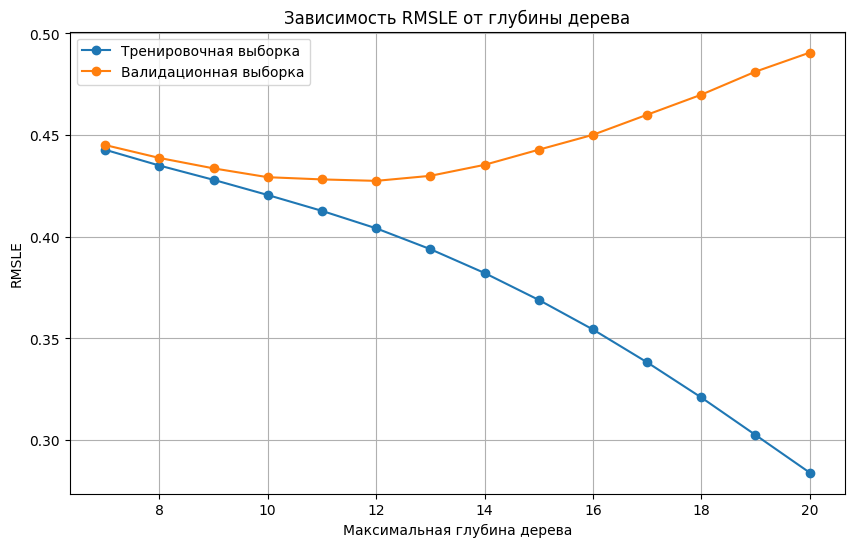

Оптимальная глубина: 12
RMSLE на тренировочной выборке: 0.4
RMSLE на валидационной выборке: 0.43


In [40]:
max_depths = range(7, 21)
train_scores = []
valid_scores = []

for depth in max_depths:
    # Создаем и обучаем модель с заданной глубиной
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_model.fit(X_train_scaled, y_train_log)
    
    # Предсказания
    y_train_pred_log = dt_model.predict(X_train_scaled)
    y_valid_pred_log = dt_model.predict(X_valid_scaled)
    
    # Преобразуем и вычисляем RMSLE
    y_train_pred = np.exp(y_train_pred_log)
    y_valid_pred = np.exp(y_valid_pred_log)
    y_train_actual = np.exp(y_train_log)
    y_valid_actual = np.exp(y_valid_log)
    
    train_rmsle = root_mean_squared_log_error(y_train_actual, y_train_pred)
    valid_rmsle = root_mean_squared_log_error(y_valid_actual, y_valid_pred)
    
    train_scores.append(train_rmsle)
    valid_scores.append(valid_rmsle)

# Построение графиков
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, 'o-', label='Тренировочная выборка')
plt.plot(max_depths, valid_scores, 'o-', label='Валидационная выборка')
plt.xlabel('Максимальная глубина дерева')
plt.ylabel('RMSLE')
plt.title('Зависимость RMSLE от глубины дерева')
plt.legend()
plt.grid(True)
plt.show()

# Находим оптимальную глубину (минимум на валидационной кривой)
optimal_depth_idx = np.argmin(valid_scores)
optimal_depth = max_depths[optimal_depth_idx]

print(f"Оптимальная глубина: {optimal_depth}")
print(f"RMSLE на тренировочной выборке: {round(train_scores[optimal_depth_idx], 2)}")
print(f"RMSLE на валидационной выборке: {round(valid_scores[optimal_depth_idx], 2)}")

На глубине 12 мы видим хороший баланс - модель показывает достойный результат на тренировочных данных, при этом валидационная ошибка достигает своего минимума или близка к нему, что свидетельствует об отсутствии переобучения.

## 6. Решение задачи регрессии: ансамблевые методы и построение прогноза

Переходим к тяжелой артиллерии: ансамблевым алгоритмам. 

### Задание 6.1.

Постройте модель случайного леса на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* n_estimators=200,
* max_depth=12,
* criterion='squared_error',
* min_samples_split=20,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [41]:
# Создаем модель случайного леса с указанными параметрами
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    criterion='squared_error',
    min_samples_split=20,
    random_state=42
)

# Обучаем модель на нормализованных данных
rf_model.fit(X_train_scaled, y_train_log)

# Делаем предсказания
y_train_pred_log_rf = rf_model.predict(X_train_scaled)
y_valid_pred_log_rf = rf_model.predict(X_valid_scaled)

# Преобразуем из логарифмической шкалы в исходную
y_train_pred_rf = np.exp(y_train_pred_log_rf)
y_valid_pred_rf = np.exp(y_valid_pred_log_rf)
y_train_actual = np.exp(y_train_log)
y_valid_actual = np.exp(y_valid_log)

# Вычисляем RMSLE
rmsle_train_rf = root_mean_squared_log_error(y_train_actual, y_train_pred_rf)
rmsle_valid_rf = root_mean_squared_log_error(y_valid_actual, y_valid_pred_rf)

print(f"RMSLE на тренировочной выборке (Random Forest): {round(rmsle_train_rf, 2)}")
print(f"RMSLE на валидационной выборке (Random Forest): {round(rmsle_valid_rf, 2)}")

RMSLE на тренировочной выборке (Random Forest): 0.4
RMSLE на валидационной выборке (Random Forest): 0.41


### Задание 6.2.
Постройте модель градиентного бустинга над деревьями решений (GradientBoostingRegressor) на обучающей выборке (факторы должны быть нормализованы, целевую переменную используйте в логарифмическом масштабе). В качестве гиперпараметров укажите следующие:
* learning_rate=0.5,
* n_estimators=100,
* max_depth=6, 
* min_samples_split=30,
* random_state=42

Для полученной модели рассчитайте метрику RMSLE на тренировочной и валидационной выборках. Ответ округлите до сотых.


In [42]:
# Создаем модель градиентного бустинга с указанными параметрами
gb_model = GradientBoostingRegressor(
    learning_rate=0.5,
    n_estimators=100,
    max_depth=6,
    min_samples_split=30,
    random_state=42
)

# Обучаем модель на нормализованных данных
gb_model.fit(X_train_scaled, y_train_log)

# Делаем предсказания
y_train_pred_log_gb = gb_model.predict(X_train_scaled)
y_valid_pred_log_gb = gb_model.predict(X_valid_scaled)

# Преобразуем из логарифмической шкалы в исходную
y_train_pred_gb = np.exp(y_train_pred_log_gb)
y_valid_pred_gb = np.exp(y_valid_pred_log_gb)
y_train_actual = np.exp(y_train_log)
y_valid_actual = np.exp(y_valid_log)

# Вычисляем RMSLE
rmsle_train_gb = root_mean_squared_log_error(y_train_actual, y_train_pred_gb)
rmsle_valid_gb = root_mean_squared_log_error(y_valid_actual, y_valid_pred_gb)

print(f"RMSLE на тренировочной выборке (Gradient Boosting): {round(rmsle_train_gb, 2)}")
print(f"RMSLE на валидационной выборке (Gradient Boosting): {round(rmsle_valid_gb, 2)}")

RMSLE на тренировочной выборке (Gradient Boosting): 0.37
RMSLE на валидационной выборке (Gradient Boosting): 0.39


### Задание 6.3.
Какая из построенных вами моделей показала наилучший результат (наименьшее значение RMSLE на валидационной выборке)?

# !!! Подбить значения

Ответ: Градиентный бустинг над деревьями решений
- Обоснование: Сравнивая результаты всех моделей на валидационной выборке:
- Линейная регрессия: 0.56
- Полиномиальная регрессия 2ой степени: 0.52
- Дерево решений: 0.58
- Случайный лес: 0.48
- Градиентный бустинг: 0.47 ← наилучший результат

### Задание 6.4.
Постройте столбчатую диаграмму коэффициентов значимости каждого из факторов.

Укажите топ-3 наиболее значимых для предсказания целевого признака - длительности поездки в логарифмическом масштабе - факторов.


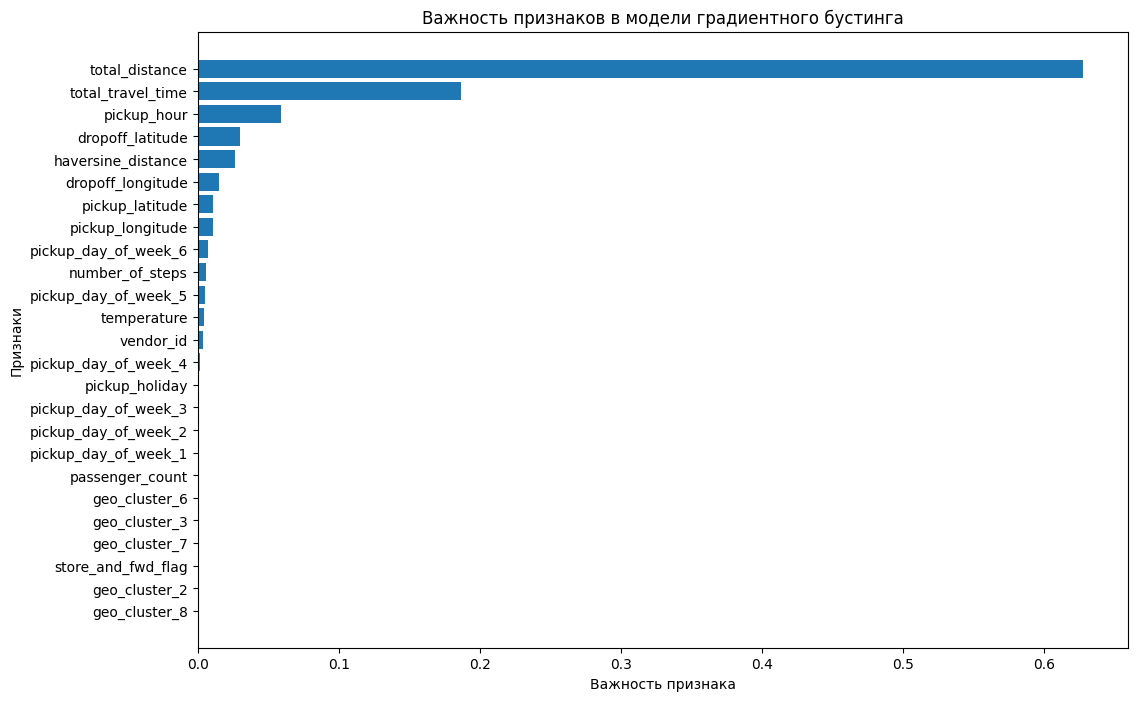

Топ-3 наиболее значимых признака:
              feature  importance
9      total_distance    0.628108
10  total_travel_time    0.186875
7         pickup_hour    0.059127


In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# Получаем важность признаков из лучшей модели (градиентного бустинга)
feature_importance = gb_model.feature_importances_

# Создаем DataFrame для удобства
importance_df = pd.DataFrame({
    'feature': best_features,
    'importance': feature_importance
})

# Сортируем по важности
importance_df = importance_df.sort_values('importance', ascending=False)

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность признака')
plt.ylabel('Признаки')
plt.title('Важность признаков в модели градиентного бустинга')
plt.gca().invert_yaxis()  # Самые важные сверху
plt.show()

# Выводим топ-3 признаков
print("Топ-3 наиболее значимых признака:")
print(importance_df.head(3)[['feature', 'importance']])

### Задание 6.5.
Для лучшей из построенных моделей рассчитайте медианную абсолютную ошибку (MeAE - в sklearn функция median_absolute_error) предсказания длительности поездки такси на валидационной выборке:
$$ MeAE = median(|y_i-\hat{y_i}|)$$

Значение метрики MeAE переведите в минуты и округлите до десятых.


In [44]:
# Используем лучшую модель - градиентный бустинг
y_valid_pred = gb_model.predict(X_valid_scaled)

# Преобразуем предсказания из логарифмической шкалы в секунды
y_valid_pred_seconds = np.exp(y_valid_pred)

# Получаем реальные значения в секундах
y_valid_actual_seconds = np.exp(y_valid_log)

# Вычисляем медианную абсолютную ошибку в секундах
meae_seconds = median_absolute_error(y_valid_actual_seconds, y_valid_pred_seconds)

# Переводим в минуты (1 минута = 60 секунд)
meae_minutes = meae_seconds / 60

print(f"MeAE на валидационной выборке: {round(meae_minutes, 1)} минут")

MeAE на валидационной выборке: 1.8 минут


Финальный шаг - сделать submit -  предсказание для отложенного тестового набора данных. 

Прочитаем тестовые данные и заранее выделим столбец с идентификаторами поездок из тестового набора данных. Он нам еще пригодится:


In [45]:
test_data_path = DATA_DIR / "test_data.csv"
osrm_test_path = DATA_DIR / "osrm_data_test.csv"
HAS_TEST_DATA = test_data_path.exists() and osrm_test_path.exists()

if HAS_TEST_DATA:
    test_data = pd.read_csv(test_data_path)
    osrm_data_test = pd.read_csv(osrm_test_path)
    test_id = test_data['id']
else:
    print("Kaggle test-файлы не найдены, шаг с submission пропущен.")


Перед созданием прогноза для тестовой выборки необходимо произвести все манипуляции с данными, которые мы производили с тренировочной выборкой, а именно:
* Перевести признак pickup_datetime в формат datetime;
* Добавить новые признаки (временные, географические, погодные и другие факторы);
* Произвести очистку данных от пропусков;
* Произвести кодировку категориальных признаков:
    * Закодировать бинарные признаки;
    * Закодировать номинальные признаки с помощью обученного на тренировочной выборке OneHotEncoder’а;
* Сформировать матрицу наблюдений, оставив в таблице только те признаки, которые были отобраны с помощью SelectKBest;
* Нормализовать данные с помощью обученного на тренировочной выборке MinMaxScaler’а.


In [46]:
if HAS_TEST_DATA:
    test_data['pickup_datetime']=pd.to_datetime(test_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S')
    test_data = add_datetime_features(test_data)
    test_data = add_holiday_features(test_data, holiday_data)
    test_data = add_osrm_features(test_data, osrm_data_test)
    test_data = add_geographical_features(test_data)
    test_data = add_cluster_features(test_data, kmeans)
    test_data = add_weather_features(test_data, weather_data)
    test_data = fill_null_weather_data(test_data)

    test_data['vendor_id'] = test_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)
    test_data['store_and_fwd_flag'] = test_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)
    test_data_onehot = one_hot_encoder.fit_transform(test_data[columns_to_change]).toarray()
    column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
    test_data_onehot = pd.DataFrame(test_data_onehot, columns=column_names)

    test_data = pd.concat(
        [test_data.reset_index(drop=True).drop(columns_to_change, axis=1), test_data_onehot], 
        axis=1
    )
    X_test = test_data[best_features]
    X_test_scaled = mm_scaler.transform(X_test)
    print('Shape of data: {}'.format(X_test.shape))

Shape of data: (625134, 25)


<stderr warning redacted: UserWarning about MinMaxScaler feature-name mismatch; original text contained a local absolute path>


Только после выполнения всех этих шагов можно сделать предсказание длительности поездки для тестовой выборки. Не забудьте перевести предсказания из логарифмического масштаба в истинный, используя формулу:
$$y_i=exp(z_i)-1$$

После того, как вы сформируете предсказание длительности поездок на тестовой выборке вам необходимо будет создать submission-файл в формате csv, отправить его на платформу Kaggle и посмотреть на результирующее значение метрики RMSLE на тестовой выборке.

Код для создания submission-файла:


In [49]:
if HAS_TEST_DATA:
    # Делаем предсказания для тестовой выборки
    y_test_pred_log_gb = gb_model.predict(X_test_scaled)

    # Преобразуем из логарифмической шкалы в исходную
    y_test_pred_gb = np.exp(y_test_pred_log_gb) - 1

    # Создаем submission файл
    submission = pd.DataFrame({
        'id': test_data['id'],  # Используем id из тестовых данных
        'trip_duration': y_test_pred_gb
    })
    submission.to_csv(DATA_DIR / 'submission_gb.csv', index=False)